In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
import scipy.stats as stats

In [2]:
data = pd.read_csv("dataset.csv")

In [3]:
Column_details = pd.read_csv("dataset_variable_description.csv")

In [4]:
Column_details

,Columns name,Description
0,household_id,Unique Id indicating a single household
1,total_income,Position in the income quartile of a household
2,union_name,Name of the Union where the household situated
3,user_id,Unique Id indicating a single user
4,profile_name,Name of the user
5,father_name,Father's name of the user
6,mother_name,Mother's name of the user
7,birthday,Birthday of the user
8,age,Age of the user
9,gender,Gender of the user


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  29999 non-null  int64  
 1   household_id                29999 non-null  int64  
 2   total_income                29999 non-null  object 
 3   union_name                  29999 non-null  object 
 4   user_id                     29999 non-null  int64  
 5   birthday                    29999 non-null  object 
 6   age                         29999 non-null  int64  
 7   gender                      29999 non-null  object 
 8   is_poor                     29999 non-null  int64  
 9   is_freedom_fighter          29999 non-null  int64  
 10  had_stroke                  29999 non-null  int64  
 11  has_cardiovascular_disease  29999 non-null  int64  
 12  disabilities_name           29999 non-null  object 
 13  diabetic                    299

In [6]:
data.head(10)

,Unnamed: 0,household_id,total_income,union_name,user_id,birthday,age,gender,is_poor,is_freedom_fighter,...,RESULT_STAT_BMI,SUGAR,TAG_NAME,RESULT_STAT_SUGAR,PULSE_RATE,RESULT_STAT_PR,SPO2,RESULT_STAT_SPO2,MUAC,RESULT_STAT_MUAC
0,1,241175,Lower class,KOLA,988794,2001-11-05 18:00:00,19,Male,0,0,...,NaN,NaN,NaN,NaN,96.0,Normal,97.0,Normal,NaN,NaN
1,2,241176,Lower class,KOLA,988796,2000-06-18 18:00:00,20,Female,0,0,...,NaN,NaN,NaN,NaN,89.0,Normal,NaN,NaN,NaN,NaN
2,3,241179,Lower class,KOLA,988802,1978-06-04 18:00:00,42,Male,0,0,...,NaN,NaN,NaN,NaN,69.0,Normal,NaN,NaN,NaN,NaN
3,4,241180,Lower class,KOLA,988807,1956-02-02 18:00:00,64,Female,0,0,...,NaN,8.72,Random,Normal,85.0,Normal,NaN,NaN,NaN,NaN
4,5,241181,Lower class,KOLA,988809,1996-12-25 18:00:00,23,Female,0,0,...,NaN,NaN,NaN,NaN,101.0,High,NaN,NaN,NaN,NaN
5,6,241182,Lower class,KOLA,988811,1997-05-31 18:00:00,23,Male,0,0,...,NaN,NaN,NaN,NaN,87.0,Normal,NaN,NaN,NaN,NaN
6,7,241182,Lower class,KOLA,988812,1997-05-31 18:00:00,23,Female,0,0,...,NaN,NaN,NaN,NaN,90.0,Normal,NaN,NaN,NaN,NaN
7,8,241183,Lower class,KOLA,988815,1953-05-07 18:00:00,67,Female,0,0,...,NaN,NaN,NaN,NaN,70.0,Normal,NaN,NaN,NaN,NaN
8,9,241184,Lower class,KOLA,988817,2004-02-06 18:00:00,16,Female,0,0,...,NaN,NaN,NaN,NaN,61.0,Normal,NaN,NaN,NaN,NaN
9,10,241185,Lower class,KOLA,988819,1963-02-06 18:00:00,57,Male,0,0,...,NaN,NaN,NaN,NaN,61.0,Normal,NaN,NaN,NaN,NaN


In [7]:
data.isnull().sum()

Unnamed: 0                        0
household_id                      0
total_income                      0
union_name                        0
user_id                           0
birthday                          0
age                               0
gender                            0
is_poor                           0
is_freedom_fighter                0
had_stroke                        0
has_cardiovascular_disease        0
disabilities_name                 0
diabetic                          0
profile_hypertensive              0
SYSTOLIC                       2399
DIASTOLIC                      2399
RESULT_STAT_BP                 2399
HEIGHT                        28871
WEIGHT                        28871
BMI                           28871
RESULT_STAT_BMI               28871
SUGAR                         28416
TAG_NAME                      28416
RESULT_STAT_SUGAR             28416
PULSE_RATE                     2544
RESULT_STAT_PR                 2544
SPO2                        

In [8]:
data.groupby(["gender"]).agg({"age":"count"})

,age
gender,
Female,23236
Male,6763


In [9]:
data.columns

Index(['Unnamed: 0', 'household_id', 'total_income', 'union_name', 'user_id',
       'birthday', 'age', 'gender', 'is_poor', 'is_freedom_fighter',
       'had_stroke', 'has_cardiovascular_disease', 'disabilities_name',
       'diabetic', 'profile_hypertensive', 'SYSTOLIC', 'DIASTOLIC',
       'RESULT_STAT_BP', 'HEIGHT', 'WEIGHT', 'BMI', 'RESULT_STAT_BMI', 'SUGAR',
       'TAG_NAME', 'RESULT_STAT_SUGAR', 'PULSE_RATE', 'RESULT_STAT_PR', 'SPO2',
       'RESULT_STAT_SPO2', 'MUAC', 'RESULT_STAT_MUAC'],
      dtype='object')

In [10]:
duplicate = data.duplicated(subset = ['union_name', 'user_id', 'birthday'])

In [11]:
duplicate.sum() #No dulicate values.

np.int64(0)

In [12]:
data['gender'].nunique()

2

In [13]:
data['gender'].value_counts() #Imblaced

gender
Female    23236
Male       6763
Name: count, dtype: int64

In [14]:
data["is_poor"].nunique() 

1

In [15]:
data["is_poor"].value_counts() #Everyone Poor people?

is_poor
0    29999
Name: count, dtype: int64

In [16]:
data["has_cardiovascular_disease"].value_counts() #Out of 29999, Only 34 persons have CVD.

has_cardiovascular_disease
0    29965
1       34
Name: count, dtype: int64

### BMI

In [17]:
data1 = data[['HEIGHT', 'WEIGHT', 'BMI', 'RESULT_STAT_BMI']].copy()

In [18]:
data1.dropna(inplace = True)

In [19]:
data1.isnull().sum()

HEIGHT             0
WEIGHT             0
BMI                0
RESULT_STAT_BMI    0
dtype: int64

In [20]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1128 entries, 365 to 29667
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   HEIGHT           1128 non-null   float64
 1   WEIGHT           1128 non-null   float64
 2   BMI              1128 non-null   float64
 3   RESULT_STAT_BMI  1128 non-null   object 
dtypes: float64(3), object(1)
memory usage: 44.1+ KB


In [21]:
data1["HEIGHT"].describe()

count    1128.000000
mean      147.798502
std        22.769384
min        35.560000
25%       137.160000
50%       152.400000
75%       162.560000
max       243.840000
Name: HEIGHT, dtype: float64

In [22]:
custom_stats = data['BMI'].agg(['mean', 'median', 'std', 'max'])
print(custom_stats)

mean      22.736490
median    21.958377
std        6.036540
max       67.932934
Name: BMI, dtype: float64


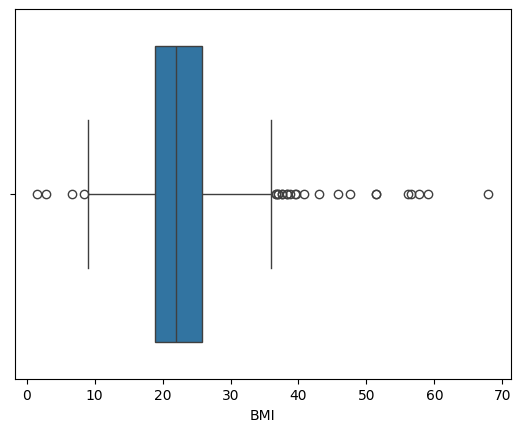

In [23]:
sns.boxplot(data = data1, x = "BMI")
plt.show()

In [24]:
outlier = data1[data1["BMI"] > 40].copy()

In [25]:
outlier

,HEIGHT,WEIGHT,BMI,RESULT_STAT_BMI
4274,35.56,6.5,51.403164,Obesity
4446,71.12,26.0,51.403164,Obesity
11308,129.54,95.0,56.612954,Morbid Obesity
11315,129.54,97.0,57.804806,Morbid Obesity
11523,99.06,40.0,40.762738,Morbid Obesity
11698,99.06,55.0,56.048764,Morbid Obesity
13101,139.70,84.0,43.041408,Morbid Obesity
18263,124.46,71.0,45.835160,Morbid Obesity
18266,93.98,42.0,47.553053,Morbid Obesity
21621,93.98,60.0,67.932934,Morbid Obesity


### Overall Missing value Handle

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  29999 non-null  int64  
 1   household_id                29999 non-null  int64  
 2   total_income                29999 non-null  object 
 3   union_name                  29999 non-null  object 
 4   user_id                     29999 non-null  int64  
 5   birthday                    29999 non-null  object 
 6   age                         29999 non-null  int64  
 7   gender                      29999 non-null  object 
 8   is_poor                     29999 non-null  int64  
 9   is_freedom_fighter          29999 non-null  int64  
 10  had_stroke                  29999 non-null  int64  
 11  has_cardiovascular_disease  29999 non-null  int64  
 12  disabilities_name           29999 non-null  object 
 13  diabetic                    299

In [27]:
# 1. Drop Highlly missing value column
data = data.iloc[:, 0:29]

In [28]:
# 3. High Missingness columns
high_missing_numeric = ['HEIGHT', 'WEIGHT', 'BMI', 'SUGAR', 'SPO2']
for col in high_missing_numeric:
    data[f'{col}_measured'] = data[col].notnull().astype(int)

In [29]:
# Fill high-missingness categorical columns with a descriptive category
high_missing_categorical = ['RESULT_STAT_BMI', 'TAG_NAME', 'RESULT_STAT_SUGAR', 'RESULT_STAT_SPO2']
for col in high_missing_categorical:
    data[col] = data[col].fillna('Not Measured')

In [30]:
# 4. Handle Low Missingness columns
data['age_group'] = pd.cut(data['age'], bins=[0, 18, 35, 50, 65, 100], labels=['<18', '18-35', '36-50', '51-65', '65+'])

low_missing_numeric = ['SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE']
for col in low_missing_numeric:
    # Impute missing values based on the median of matching Gender and Age Groups
    data[col] = data.groupby(['gender', 'age_group'])[col].transform(lambda x: x.fillna(x.median()))
    
    # Fallback to global median if any group combinations are entirely empty
    data[col] = data[col].fillna(data[col].median())

C:\Users\ACCESS\AppData\Local\Temp\ipykernel_13760\577651577.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data[col] = data.groupby(['gender', 'age_group'])[col].transform(lambda x: x.fillna(x.median()))
C:\Users\ACCESS\AppData\Local\Temp\ipykernel_13760\577651577.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data[col] = data.groupby(['gender', 'age_group'])[col].transform(lambda x: x.fillna(x.median()))
C:\Users\ACCESS\AppData\Local\Temp\ipykernel_13760\577651577.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

In [31]:
# Fill low-missingness categorical status columns with 'Unknown'
low_missing_categorical = ['RESULT_STAT_BP', 'RESULT_STAT_PR']
for col in low_missing_categorical:
    data[col] = data[col].fillna('Unknown')

# Clean up temporary helper column
data = data.drop(columns=['age_group'])

In [32]:
# Drop unnesseary column
data.drop(columns=['HEIGHT', 'WEIGHT', 'BMI', 'SUGAR', 'SPO2'], inplace=True)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  29999 non-null  int64  
 1   household_id                29999 non-null  int64  
 2   total_income                29999 non-null  object 
 3   union_name                  29999 non-null  object 
 4   user_id                     29999 non-null  int64  
 5   birthday                    29999 non-null  object 
 6   age                         29999 non-null  int64  
 7   gender                      29999 non-null  object 
 8   is_poor                     29999 non-null  int64  
 9   is_freedom_fighter          29999 non-null  int64  
 10  had_stroke                  29999 non-null  int64  
 11  has_cardiovascular_disease  29999 non-null  int64  
 12  disabilities_name           29999 non-null  object 
 13  diabetic                    299

In [34]:
data["union_name"].nunique()

16

In [35]:
# data.to_excel("Clean_data.xlsx", index=False)

### Correlation Analysis

In [36]:
df_encoded = data.copy()

In [37]:
# Gender Binary Mapping
gender_map = {'Female': 0, 'Male': 1}

# Income Class Mapping
income_map = {
    'Lower class': 0, 
    'Lower-middle class': 1, 
    'Middle class': 2, 
    'Upper class': 3
}


# CONVERTING THE COLUMNS
df_encoded['gender'] = df_encoded['gender'].map(gender_map)
df_encoded['total_income'] = df_encoded['total_income'].map(income_map)

# Convert boolean flags directly to integers (0 or 1)
df_encoded['diabetic'] = df_encoded['diabetic'].astype(int)
df_encoded['profile_hypertensive'] = df_encoded['profile_hypertensive'].astype(int)


df_encoded['union_name'] = pd.factorize(df_encoded['union_name'])[0]

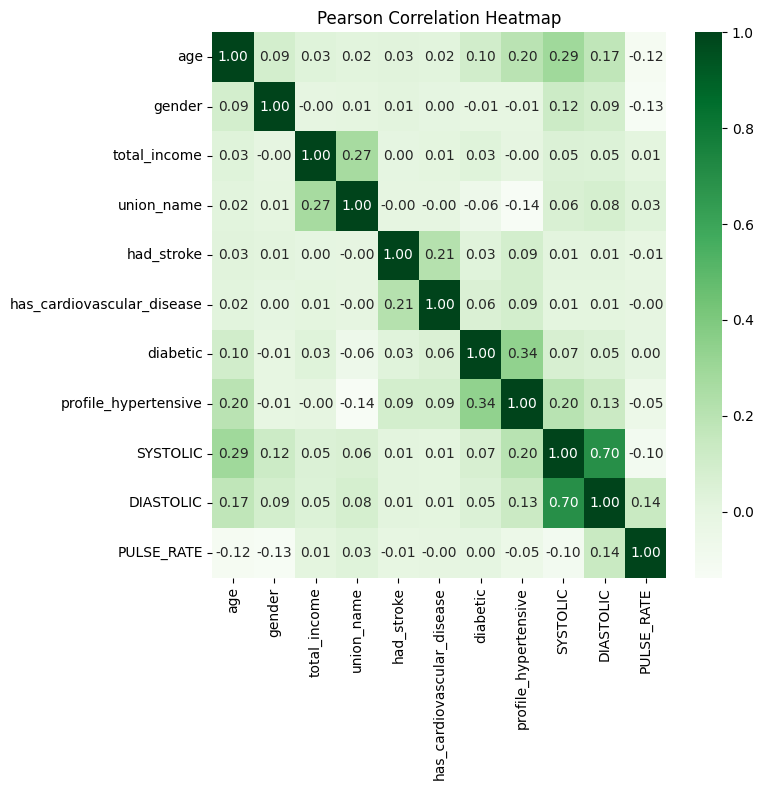

In [38]:
cols_to_correlate = [
    'age', 'gender', 'total_income', 'union_name', 
    'had_stroke', 'has_cardiovascular_disease', 'diabetic', 'profile_hypertensive',
    'SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE']

# Use Spearman Correlation as it handles ordinal/ranked data cleanly
pearson_corr = df_encoded[cols_to_correlate].corr(method='pearson')


fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(pearson_corr, annot=True, cmap='Greens', fmt=".2f", ax=ax, cbar=True)
ax.set_title("Pearson Correlation Heatmap")

plt.tight_layout()
plt.savefig('pearson_correlation_heatmap.png')

### Test Normality

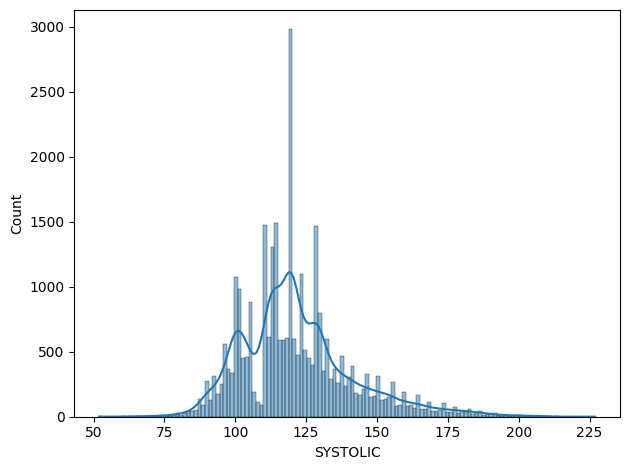

In [51]:
sns.histplot(data=data, x="SYSTOLIC", kde=True)
plt.tight_layout()
plt.savefig('systolic_normality_check.png')

In [54]:
# Extract parameters for the baseline normal distribution comparison
sample_mean = data['SYSTOLIC'].mean()
sample_std = data['SYSTOLIC'].std()

# Execute the K-S Test
ks_stat, p_val = stats.kstest(data['SYSTOLIC'], 'norm', args=(sample_mean, sample_std))

# Print outputs
print(f"Kolmogorov-Smirnov Statistic: {ks_stat:.5f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: Statistically Significant (Reject Normality)")
else:
    print("Result: Not Significant (Fail to Reject Normality)")

Kolmogorov-Smirnov Statistic: 0.09679
p-value: 4.4446e-245
Result: Statistically Significant (Reject Normality)


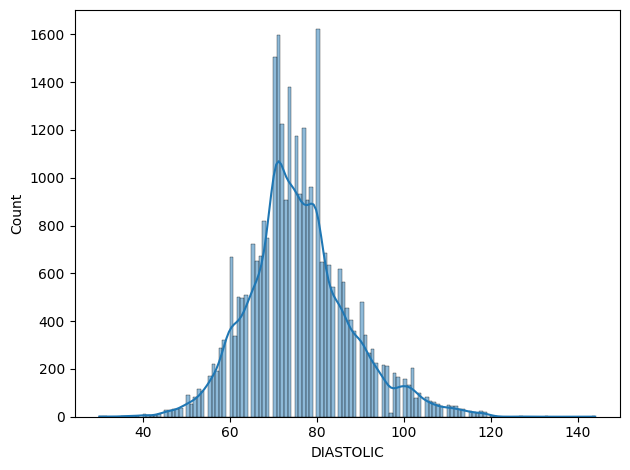

In [52]:
sns.histplot(data=data, x="DIASTOLIC", kde=True)
plt.tight_layout()
plt.savefig('DIASTOLIC_normality_check.png')

In [55]:
# Extract parameters for the baseline normal distribution comparison
sample_mean = data['DIASTOLIC'].mean()
sample_std = data['DIASTOLIC'].std()

# Execute the K-S Test
ks_stat, p_val = stats.kstest(data['DIASTOLIC'], 'norm', args=(sample_mean, sample_std))

# Print outputs
print(f"Kolmogorov-Smirnov Statistic: {ks_stat:.5f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: Statistically Significant (Reject Normality)")
else:
    print("Result: Not Significant (Fail to Reject Normality)")

Kolmogorov-Smirnov Statistic: 0.07908
p-value: 1.2742e-163
Result: Statistically Significant (Reject Normality)


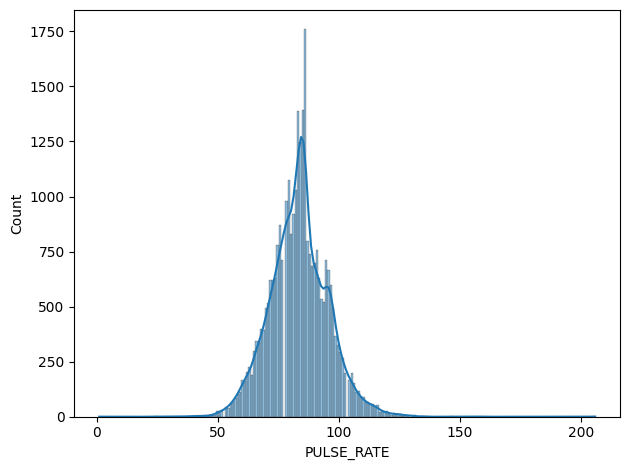

In [53]:
sns.histplot(data=data, x="PULSE_RATE", kde=True)
plt.tight_layout()
plt.savefig('PULSE_RATE_normality_check.png')

In [56]:
# Extract parameters for the baseline normal distribution comparison
sample_mean = data['PULSE_RATE'].mean()
sample_std = data['PULSE_RATE'].std()

# Execute the K-S Test
ks_stat, p_val = stats.kstest(data['PULSE_RATE'], 'norm', args=(sample_mean, sample_std))

# Print outputs
print(f"Kolmogorov-Smirnov Statistic: {ks_stat:.5f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: Statistically Significant (Reject Normality)")
else:
    print("Result: Not Significant (Fail to Reject Normality)")

Kolmogorov-Smirnov Statistic: 0.06393
p-value: 4.7954e-107
Result: Statistically Significant (Reject Normality)


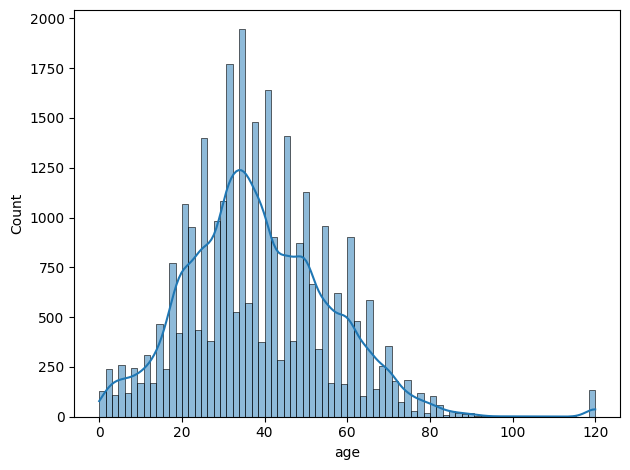

In [57]:
sns.histplot(data=data, x="age", kde=True)
plt.tight_layout()
plt.savefig('age_normality_check.png')

In [58]:
# Extract parameters for the baseline normal distribution comparison
sample_mean = data['age'].mean()
sample_std = data['age'].std()

# Execute the K-S Test
ks_stat, p_val = stats.kstest(data['age'], 'norm', args=(sample_mean, sample_std))

# Print outputs
print(f"Kolmogorov-Smirnov Statistic: {ks_stat:.5f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("Result: Statistically Significant (Reject Normality)")
else:
    print("Result: Not Significant (Fail to Reject Normality)")

Kolmogorov-Smirnov Statistic: 0.06628
p-value: 4.9029e-115
Result: Statistically Significant (Reject Normality)


### Find Statistically significance

In [39]:
# Define targets and variables
outcomes = ['had_stroke', 'has_cardiovascular_disease', 'diabetic', 'profile_hypertensive']
categorical_features = ['gender', 'total_income', 'union_name', 'had_stroke','has_cardiovascular_disease', 'diabetic', 'profile_hypertensive']
numerical_features = ['age', 'SYSTOLIC', 'DIASTOLIC', 'PULSE_RATE']

`CHI-SQUARE Test`

In [40]:
print("=== CATEGORICAL FEATURES SIGNIFICANCE (CHI-SQUARE) ===")
for target in outcomes:
    for feature in categorical_features:
        if feature == target:
            continue
        
        contingency_table = pd.crosstab(data[feature], data[target])
        _, p, _, _ = chi2_contingency(contingency_table)
        status = "SIGNIFICANT" if p < 0.05 else "NOT SIGNIFICANT"
        print(f"Target: {target:28} | Feature: {feature:28} | p-val: {p:.4e} | Result: {status}")

=== CATEGORICAL FEATURES SIGNIFICANCE (CHI-SQUARE) ===
Target: had_stroke                   | Feature: gender                       | p-val: 3.1248e-02 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: total_income                 | p-val: 8.2535e-01 | Result: NOT SIGNIFICANT
Target: had_stroke                   | Feature: union_name                   | p-val: 1.3086e-08 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: has_cardiovascular_disease   | p-val: 1.9543e-252 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: diabetic                     | p-val: 6.0525e-06 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: profile_hypertensive         | p-val: 1.9941e-52 | Result: SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: gender                       | p-val: 7.3168e-01 | Result: NOT SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: total_income                 | p-val: 1.7706e-01 | Resu

`T-TEST`

In [41]:
print("\n=== NUMERICAL FEATURES SIGNIFICANCE (T-TEST) ===")
for target in outcomes:
    for feature in numerical_features:
        g0 = data[data[target] == 0][feature]
        g1 = data[data[target] == 1][feature]
        
        _, p = ttest_ind(g0, g1, equal_var=False)
        status = "SIGNIFICANT" if p < 0.05 else "NOT SIGNIFICANT"
        print(f"Target: {target:28} | Feature: {feature:12} | p-val: {p:.4e} | Result: {status}")


=== NUMERICAL FEATURES SIGNIFICANCE (T-TEST) ===
Target: had_stroke                   | Feature: age          | p-val: 1.4723e-07 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: SYSTOLIC     | p-val: 1.7772e-02 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: DIASTOLIC    | p-val: 6.8728e-03 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: PULSE_RATE   | p-val: 2.0349e-01 | Result: NOT SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: age          | p-val: 5.3789e-05 | Result: SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: SYSTOLIC     | p-val: 6.9265e-02 | Result: NOT SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: DIASTOLIC    | p-val: 2.1417e-03 | Result: SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: PULSE_RATE   | p-val: 8.6461e-01 | Result: NOT SIGNIFICANT
Target: diabetic                     | Feature: age          | p-val: 4.9803e-94 | Result: SIGNIFICANT
Target: dia

`Mann-Whitney U test`

In [61]:
print("\n=== NUMERICAL FEATURES SIGNIFICANCE (Mann-Whitney U test-TEST) ===")
for target in outcomes:
    for feature in numerical_features:
        g0 = data[data[target] == 0][feature]
        g1 = data[data[target] == 1][feature]
        
        u_stat, p_value = mannwhitneyu(g0, g1, alternative='two-sided')
        status = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
        print(f"Target: {target:28} | Feature: {feature:12} | p-val: {p:.4e} | Result: {status}")


=== NUMERICAL FEATURES SIGNIFICANCE (Mann-Whitney U test-TEST) ===
Target: had_stroke                   | Feature: age          | p-val: 8.7403e-15 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: SYSTOLIC     | p-val: 8.7403e-15 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: DIASTOLIC    | p-val: 8.7403e-15 | Result: SIGNIFICANT
Target: had_stroke                   | Feature: PULSE_RATE   | p-val: 8.7403e-15 | Result: NOT SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: age          | p-val: 8.7403e-15 | Result: SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: SYSTOLIC     | p-val: 8.7403e-15 | Result: SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: DIASTOLIC    | p-val: 8.7403e-15 | Result: SIGNIFICANT
Target: has_cardiovascular_disease   | Feature: PULSE_RATE   | p-val: 8.7403e-15 | Result: NOT SIGNIFICANT
Target: diabetic                     | Feature: age          | p-val: 8.7403e-15 | Result: SIGNIFICA

`Cardiovascular Disease`
- Select most related variable for Cardiovascular Disease;
- `age, SYSTOLIC, DIASTOLIC, had_stroke, union_name, diabetic, profile_hypertensive`.


`Had Strock`
- Select most related variable for Had Strock;
- `gender, age, SYSTOLIC, DIASTOLIC, union_name, has_cardiovascular_disease, diabetic, profile_hypertensive`.


`Diabetic`
- Select most related variable for Diabetic;
- `age, total_income, SYSTOLIC, DIASTOLIC, union_name, has_cardiovascular_disease, diabetic, profile_hypertensive`.


`Profile Hypertensive`
- Select most related variable for Hypertensive;
- `age, total_income, SYSTOLIC, DIASTOLIC, PULS_RATE, union_name, has_cardiovascular_disease, diabetic, profile_hypertensive`.